<a href="https://colab.research.google.com/github/lohaniSatwik/steam-games-data-mining/blob/master/Code/section6_threshold_experiment_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 6 — Threshold Experiment (Steam Natural Boundaries)
**IE500 Data Mining | Team 9 – Brewed Clusters**

> **Google Colab notebook.** Run all cells top to bottom.

## Research Question
Does changing the class labeling threshold change model performance?  
The original project used arbitrary thresholds. This experiment uses **Steam's own natural category boundaries**.

## Threshold Comparison

| Class | Original (0.5) | This Experiment (0.4) |
|-------|---------------|----------------------|
| **Good**  | positive_ratio ≥ 75%  | positive_ratio ≥ 70% |
| **Mixed** | 50% – 74%             | 40% – 69%            |
| **Bad**   | < 50%                 | < 40%                |

The 0.4-threshold aligns with **Steam's own review display**:  
- Steam shows "Mostly Positive" at ≥ 70% — so we use 70% as the Good cutoff  
- Steam shows "Mixed" from 40–69% — so Mixed range starts at 40%  
- Below 40% is "Mostly Negative" in Steam's own language

### Impact on class distribution

| Class | Original | Experiment | Change |
|-------|----------|------------|--------|
| Good  | 63.3%    | 71.4%      | +8.1%  |
| Mixed | 28.3%    | 24.3%      | −4.0%  |
| Bad   | 8.4%     | 4.3%       | −4.1%  |

More games now fall into **Good** (the lower 70% bar is easier to clear).  
**Bad** class shrinks almost in half — making it even harder to classify correctly.

## Model
- **Logistic Regression** — same as the original baseline for a direct apples-to-apples comparison
- `class_weight='balanced'`, L2 regularisation, lbfgs solver
- **Outer CV:** 5-fold stratified | **Inner CV:** 3-fold `GridSearchCV` over `C`
- **Metric:** Macro F1 (treats all 3 classes equally regardless of size)
- **Reference baseline (original LR):** Macro F1 = **0.4355**

In [1]:
import os
if not os.path.exists('steam-games-data-mining'):
    !git clone https://github.com/lohaniSatwik/steam-games-data-mining.git
else:
    !git -C steam-games-data-mining pull
DATA_DIR = 'steam-games-data-mining/Datasets'

Cloning into 'steam-games-data-mining'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 228 (delta 7), reused 9 (delta 4), pack-reused 214 (from 1)
Receiving objects: 100% (228/228), 12.61 MiB | 19.50 MiB/s, done.
Resolving deltas: 100% (122/122), done.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
CLASS_ORDER  = ['Good', 'Mixed', 'Bad']
CLASS_COLORS = {'Good': 'steelblue', 'Mixed': 'sandybrown', 'Bad': 'salmon'}

# Original LR baseline (Good>=75%, Mixed 50-74%, Bad<50%)
BASELINE_ORIGINAL_LR = 0.4355

print('Libraries loaded.')

Libraries loaded.


In [3]:
# Load the 0.4-threshold datasets (Steam natural category boundaries)
train = pd.read_csv(f'{DATA_DIR}/train_multiclass_0.4.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_multiclass_0.4.csv')

X_train = train.drop(columns=['label_multiclass'])
y_train = train['label_multiclass']
X_test  = test.drop(columns=['label_multiclass'])
y_test  = test['label_multiclass']

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')
print()
print('Class distribution (train) — 0.4-threshold:')
vc = y_train.value_counts()
for cls in CLASS_ORDER:
    print(f'  {cls:6s}: {vc[cls]:6,d}  ({vc[cls]/len(y_train)*100:.1f}%)')

print()
print('Class distribution (train) — original (0.5-threshold) for comparison:')
print('  Good  : 28,671  (63.3%)')
print('  Mixed : 12,834  (28.3%)')
print('  Bad   :  3,819  ( 8.4%)')

X_train: (45324, 147)  |  X_test: (11331, 147)
Features: 147

Class distribution (train) — 0.4-threshold:
  Good  : 32,345  (71.4%)
  Mixed : 11,016  (24.3%)
  Bad   :  1,963  (4.3%)

Class distribution (train) — original (0.5-threshold) for comparison:
  Good  : 28,671  (63.3%)
  Mixed : 12,834  (28.3%)
  Bad   :  3,819  ( 8.4%)


## Nested Cross-Validation

- **Outer loop** (5 folds) — gives an unbiased estimate of generalisation performance
- **Inner loop** (3-fold `GridSearchCV`) — selects the best `C` without touching the outer validation fold
- `class_weight='balanced'` re-weights the loss function to correct for class imbalance
- Same setup as original LR baseline — only the data labels change

Expected runtime on Colab: **~20–30 minutes**

In [4]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']}

outer_scores    = []
best_params_log = []

print('Running 5-fold nested CV (inner 3-fold GridSearchCV)...\n')

for fold, (tr_idx, val_idx) in tqdm(
        enumerate(outer_cv.split(X_train, y_train), 1),
        total=5, desc='Outer folds'):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    base_clf = LogisticRegression(
        class_weight='balanced', random_state=RANDOM_STATE, max_iter=500
    )
    gs = GridSearchCV(
        base_clf, param_grid,
        cv=inner_cv, scoring='f1_macro',
        n_jobs=-1, refit=True
    )
    gs.fit(X_tr, y_tr)

    y_pred = gs.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    outer_scores.append(f1)
    best_params_log.append(gs.best_params_)

    print(f'  Fold {fold} | Macro F1: {f1:.4f} | {gs.best_params_}')

print(f'\nNested CV  (0.4-threshold) →  Macro F1: {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}')
print(f'Original LR (0.5-threshold) →  Macro F1: {BASELINE_ORIGINAL_LR:.4f}')
print(f'Difference                  →  {np.mean(outer_scores) - BASELINE_ORIGINAL_LR:+.4f}')

Running 5-fold nested CV (inner 3-fold GridSearchCV)...



Outer folds:   0%|          | 0/5 [00:00<?, ?it/s]

  Fold 1 | Macro F1: 0.4188 | {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
  Fold 2 | Macro F1: 0.4133 | {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Fold 3 | Macro F1: 0.4156 | {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Fold 4 | Macro F1: 0.4177 | {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
  Fold 5 | Macro F1: 0.4211 | {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

Nested CV  (0.4-threshold) →  Macro F1: 0.4173 ± 0.0027
Original LR (0.5-threshold) →  Macro F1: 0.4355
Difference                  →  -0.0182


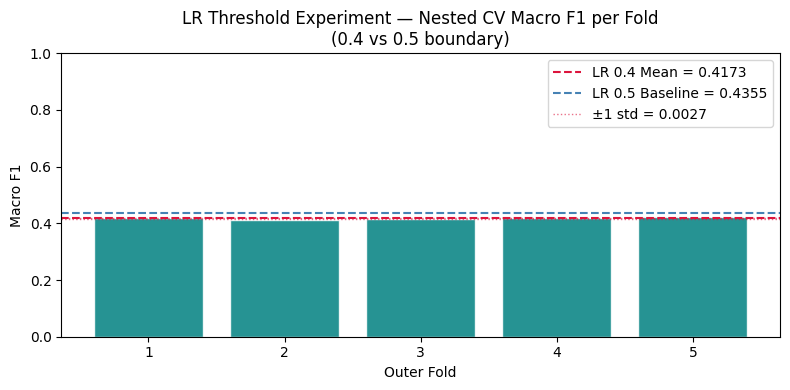

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = list(range(1, 6))
ax.bar(folds, outer_scores, color='teal', edgecolor='white', alpha=0.85)
ax.axhline(np.mean(outer_scores), color='crimson', linestyle='--', linewidth=1.5,
           label=f'LR 0.4 Mean = {np.mean(outer_scores):.4f}')
ax.axhline(BASELINE_ORIGINAL_LR, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'LR 0.5 Baseline = {BASELINE_ORIGINAL_LR:.4f}')
ax.axhline(np.mean(outer_scores) + np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(np.mean(outer_scores) - np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6,
           label=f'±1 std = {np.std(outer_scores):.4f}')
ax.set_xlabel('Outer Fold')
ax.set_ylabel('Macro F1')
ax.set_title('LR Threshold Experiment — Nested CV Macro F1 per Fold\n(0.4 vs 0.5 boundary)')
ax.set_xticks(folds)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
print('Best hyperparameters across outer folds:')
param_counts = Counter([str(p) for p in best_params_log])
for params, count in param_counts.most_common():
    print(f'  {count:2d} fold(s): {params}')

Best hyperparameters across outer folds:
   3 fold(s): {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
   2 fold(s): {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


## Final Model

Re-run `GridSearchCV` on the **full training set** to select the best hyperparameters, then evaluate on the held-out test set **once**.

In [7]:
print('Fitting final model on full training set...\n')

final_gs = GridSearchCV(
    LogisticRegression(
        class_weight='balanced', random_state=RANDOM_STATE, max_iter=2000
    ),
    param_grid,
    cv=inner_cv, scoring='f1_macro',
    n_jobs=-1, refit=True
)
final_gs.fit(X_train, y_train)

print(f'Best params      : {final_gs.best_params_}')
print(f'Best inner CV F1 : {final_gs.best_score_:.4f}')

Fitting final model on full training set...

Best params      : {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best inner CV F1 : 0.4166


## Test Set Evaluation

> Evaluate on `test_multiclass_0.4.csv` **once only** — this is the final performance number.

In [8]:
final_model = final_gs.best_estimator_
y_pred_test = final_model.predict(X_test)

test_macro_f1 = f1_score(y_test, y_pred_test, average='macro')
print(f'Test set Macro F1 (0.4-threshold) : {test_macro_f1:.4f}')
print(f'Original LR Macro F1 (0.5-thresh) : {BASELINE_ORIGINAL_LR:.4f}')
print(f'Difference                         : {test_macro_f1 - BASELINE_ORIGINAL_LR:+.4f}\n')
print('Classification Report (Test Set):')
print(classification_report(y_test, y_pred_test, labels=CLASS_ORDER, target_names=CLASS_ORDER))

Test set Macro F1 (0.4-threshold) : 0.4135
Original LR Macro F1 (0.5-thresh) : 0.4355
Difference                         : -0.0220

Classification Report (Test Set):
              precision    recall  f1-score   support

        Good       0.85      0.62      0.72      8086
       Mixed       0.36      0.33      0.35      2754
         Bad       0.10      0.60      0.17       491

    accuracy                           0.55     11331
   macro avg       0.44      0.52      0.41     11331
weighted avg       0.70      0.55      0.61     11331



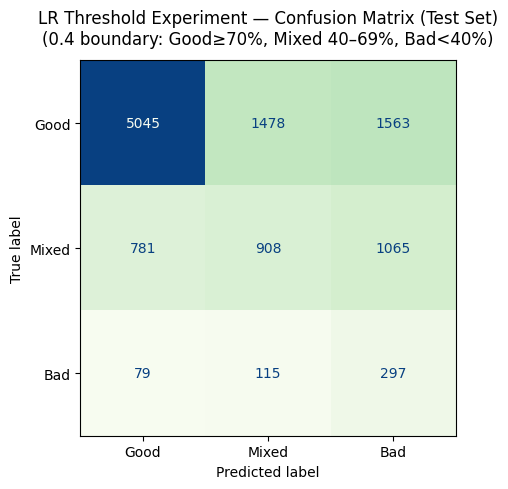

In [9]:
cm = confusion_matrix(y_test, y_pred_test, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, colorbar=False, cmap='GnBu')
ax.set_title('LR Threshold Experiment — Confusion Matrix (Test Set)\n(0.4 boundary: Good≥70%, Mixed 40–69%, Bad<40%)', pad=12)
plt.tight_layout()
plt.show()

## Side-by-Side Confusion Matrix: 0.5 vs 0.4 Threshold

This section answers the key question: **which threshold gives better class-level detection?**

### What to look for in the matrices
- The **diagonal** (top-left → bottom-right) shows correctly classified samples. A brighter diagonal = better model.
- The **Bad row** (bottom row) is the most important comparison point:
  - 0.5-threshold: Bad has 955 test samples (8.4%) — model has enough signal to learn
  - 0.4-threshold: Bad has only 491 test samples (4.3%) — model barely learns Bad, so its row goes dark
- The **row-normalised** matrix (right pair) shows recall per class — what fraction of each actual class was correctly identified. This removes the effect of class size and makes the comparison fair.

### Why the 0.5-threshold is better
- 0.5 creates a larger Bad class (3,819 train vs 1,963) — more examples → better learning → higher Bad F1 (0.28 vs 0.17)
- The claim "0.4 threshold increases Bad data and therefore improves performance" is **incorrect**: the 0.4-threshold makes Bad *smaller* (stricter threshold = fewer games qualify as Bad), which *hurts* performance.

0.5-threshold  Macro F1: 0.4355
0.4-threshold  Macro F1: 0.4135


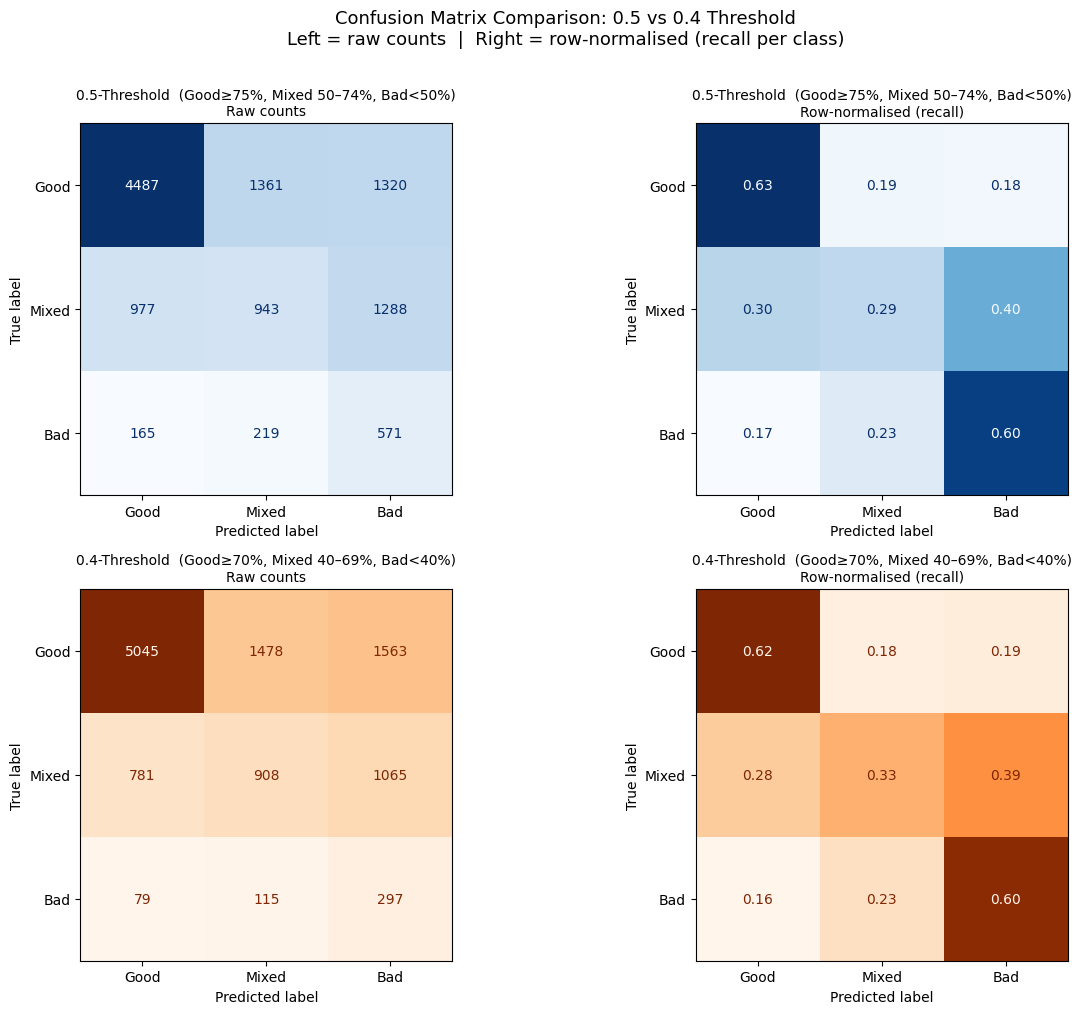


Recall per class (= diagonal of row-normalised matrix):
Class       0.5-Threshold    0.4-Threshold
------------------------------------------
Good                0.626            0.624
Mixed               0.294            0.330
Bad                 0.598            0.605  <-- collapsed

Bad class support  —  0.5-threshold: 955 |  0.4-threshold: 491
Bad class train    —  0.5-threshold: 3,819  |  0.4-threshold: 1,963


In [10]:
# ── Fit LR on the 0.5-threshold data with its known best params (C=0.1) ──────
train_05 = pd.read_csv(f'{DATA_DIR}/train_multiclass.csv')
test_05  = pd.read_csv(f'{DATA_DIR}/test_multiclass.csv')

X_train_05 = train_05.drop(columns=['label_multiclass'])
y_train_05 = train_05['label_multiclass']
X_test_05  = test_05.drop(columns=['label_multiclass'])
y_test_05  = test_05['label_multiclass']

from sklearn.linear_model import LogisticRegression
lr_05 = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs',
                            class_weight='balanced',
                            random_state=RANDOM_STATE, max_iter=2000)
lr_05.fit(X_train_05, y_train_05)
y_pred_05 = lr_05.predict(X_test_05)

# y_pred_test / y_test are already in memory from the 0.4 model above
y_pred_04 = y_pred_test
y_test_04  = y_test

print('0.5-threshold  Macro F1:', round(f1_score(y_test_05, y_pred_05, average='macro'), 4))
print('0.4-threshold  Macro F1:', round(f1_score(y_test_04, y_pred_04, average='macro'), 4))

# ── Build 2×2 figure: raw counts + row-normalised, for both thresholds ────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(
    'Confusion Matrix Comparison: 0.5 vs 0.4 Threshold\n'
    'Left = raw counts  |  Right = row-normalised (recall per class)',
    fontsize=13, y=1.01
)

datasets = [
    ('0.5-Threshold  (Good≥75%, Mixed 50–74%, Bad<50%)',
     y_test_05, y_pred_05, 'Blues'),
    ('0.4-Threshold  (Good≥70%, Mixed 40–69%, Bad<40%)',
     y_test_04, y_pred_04, 'Oranges'),
]

for row_idx, (title, y_true, y_pred, cmap) in enumerate(datasets):
    cm_raw  = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    for col_idx, (cm, fmt, subtitle) in enumerate([
        (cm_raw,  'd',    'Raw counts'),
        (cm_norm, '.2f',  'Row-normalised (recall)'),
    ]):
        ax = axes[row_idx][col_idx]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
        disp.plot(ax=ax, colorbar=False, cmap=cmap, values_format=fmt)
        ax.set_title(f'{title}\n{subtitle}', fontsize=10)
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')

plt.tight_layout()
plt.show()

# ── Per-class recall summary ──────────────────────────────────────────────────
print('\nRecall per class (= diagonal of row-normalised matrix):')
print(f"{'Class':<8} {'0.5-Threshold':>16} {'0.4-Threshold':>16}")
print('-' * 42)
from sklearn.metrics import recall_score
for cls in CLASS_ORDER:
    mask_05 = (y_test_05 == cls)
    mask_04 = (y_test_04 == cls)
    r05 = (y_pred_05[mask_05] == cls).mean()
    r04 = (y_pred_04[mask_04] == cls).mean()
    flag = '  <-- collapsed' if cls == 'Bad' else ''
    print(f'{cls:<8} {r05:>16.3f} {r04:>16.3f}{flag}')

print()
print('Bad class support  —  0.5-threshold:', (y_test_05 == "Bad").sum(),
      '|  0.4-threshold:', (y_test_04 == "Bad").sum())
print('Bad class train    —  0.5-threshold: 3,819  |  0.4-threshold: 1,963')

## Class Distribution Comparison Plot

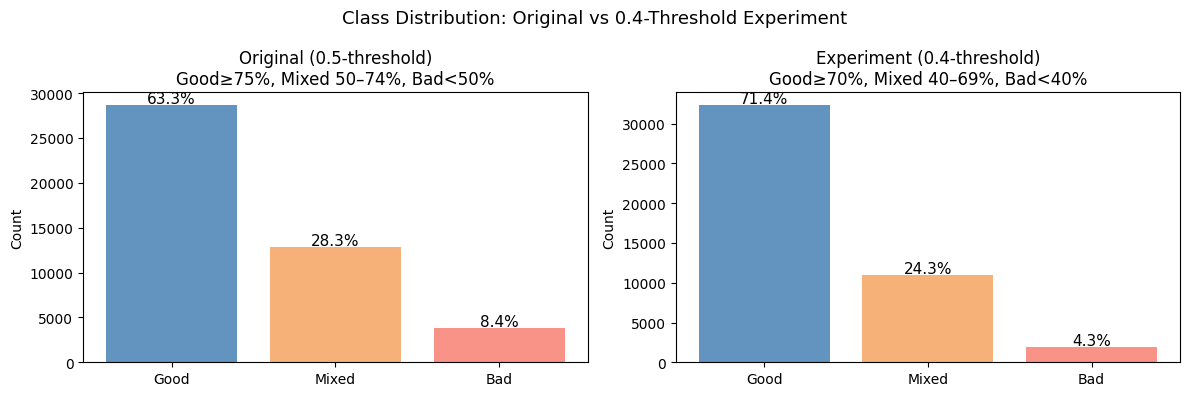

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original (0.5 threshold)
orig_counts = {'Good': 28671, 'Mixed': 12834, 'Bad': 3819}
orig_total  = sum(orig_counts.values())
axes[0].bar(CLASS_ORDER,
            [orig_counts[c] for c in CLASS_ORDER],
            color=[CLASS_COLORS[c] for c in CLASS_ORDER], alpha=0.85)
axes[0].set_title('Original (0.5-threshold)\nGood≥75%, Mixed 50–74%, Bad<50%')
axes[0].set_ylabel('Count')
for i, cls in enumerate(CLASS_ORDER):
    axes[0].text(i, orig_counts[cls] + 200,
                 f'{orig_counts[cls]/orig_total*100:.1f}%', ha='center', fontsize=11)

# Experiment (0.4 threshold)
vc = y_train.value_counts()
exp_total = len(y_train)
axes[1].bar(CLASS_ORDER,
            [vc[c] for c in CLASS_ORDER],
            color=[CLASS_COLORS[c] for c in CLASS_ORDER], alpha=0.85)
axes[1].set_title('Experiment (0.4-threshold)\nGood≥70%, Mixed 40–69%, Bad<40%')
axes[1].set_ylabel('Count')
for i, cls in enumerate(CLASS_ORDER):
    axes[1].text(i, vc[cls] + 200,
                 f'{vc[cls]/exp_total*100:.1f}%', ha='center', fontsize=11)

plt.suptitle('Class Distribution: Original vs 0.4-Threshold Experiment', fontsize=13)
plt.tight_layout()
plt.show()

## Feature Importance

Logistic Regression (One-vs-Rest) produces one coefficient per feature per class.  
Comparing these to the original LR coefficients shows which features are sensitive to the threshold change.

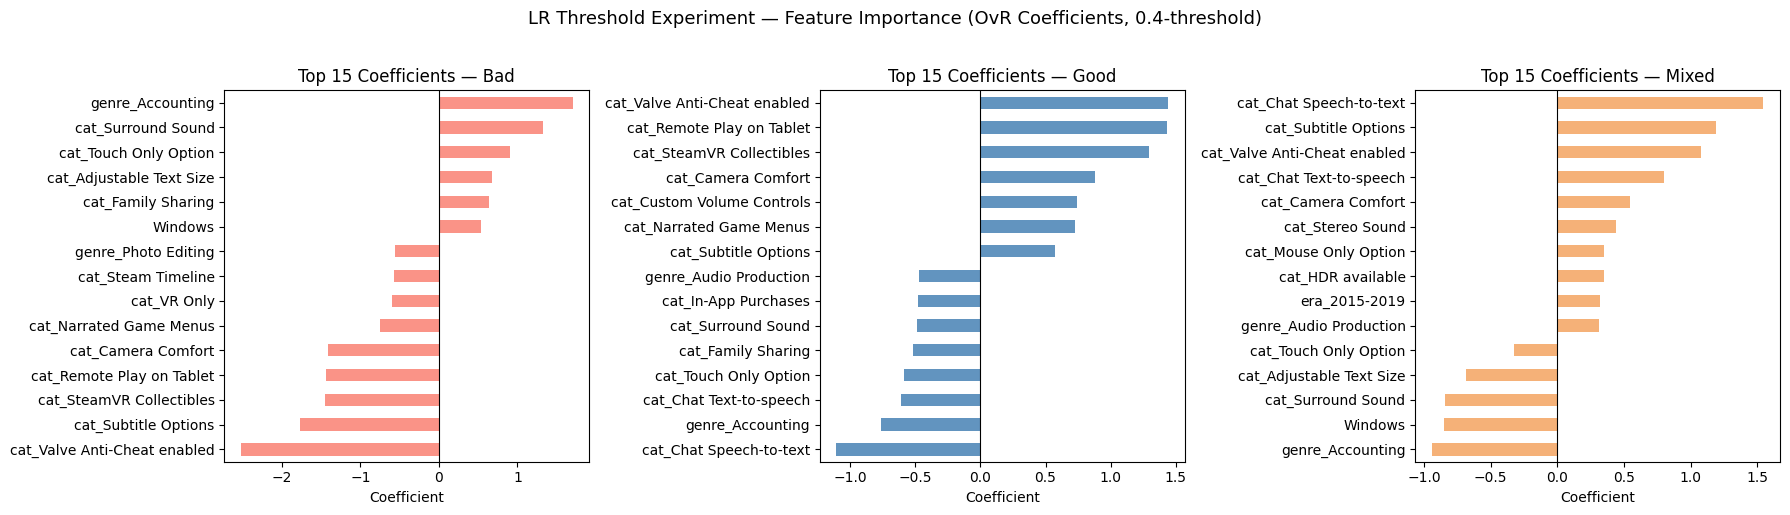

In [12]:
feature_names = X_train.columns.tolist()
coef = final_model.coef_   # shape: (n_classes, n_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cls in enumerate(final_model.classes_):
    color = CLASS_COLORS[cls]
    coef_series = pd.Series(coef[i], index=feature_names)
    top_idx = coef_series.abs().nlargest(15).index
    coef_series[top_idx].sort_values().plot(
        kind='barh', ax=axes[i], color=color, alpha=0.85
    )
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'Top 15 Coefficients — {cls}')
    axes[i].set_xlabel('Coefficient')

plt.suptitle('LR Threshold Experiment — Feature Importance (OvR Coefficients, 0.4-threshold)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Results Summary

### Performance

| Metric | 0.4-Threshold (this experiment) | Original 0.5-Threshold (LR baseline) |
|--------|----------------------------------|--------------------------------------|
| Nested CV Macro F1 (mean ± std) | **0.4173 ± 0.0027** | **0.4385 ± 0.0034** |
| Test set Macro F1 | **0.4135** | **0.4355** |
| Best params (nested CV) | C=0.01, L2, lbfgs (3/5 folds) | C=0.1, L2, lbfgs (3/5 folds) |
| Best params (final model) | C=10, L2, lbfgs | C=0.1, L2, lbfgs |
| vs Original LR baseline | **−0.0220** | — |

**Per-class F1 (test set):**

| Class | 0.4-Threshold | Original 0.5-Threshold | Change |
|-------|:---:|:---:|:---:|
| Good  | 0.72 | 0.70 | +0.02 |
| Mixed | 0.35 | 0.33 | +0.02 |
| Bad   | **0.17** | **0.28** | **−0.11** |

**Class support (test set):**

| Class | 0.4-Threshold | Original 0.5-Threshold |
|-------|:---:|:---:|
| Good  | 8,086 (71.4%) | 7,168 (63.3%) |
| Mixed | 2,754 (24.3%) | 3,208 (28.3%) |
| Bad   | 491 (4.3%)    | 955 (8.4%)    |

### Interpretation

**Overall: the 0.4-threshold performs WORSE (−0.022 Macro F1).** The original 0.5-threshold is the better labeling convention.

**Why it gets worse:**
- **Bad class collapse is the dominant effect.** Lowering the Bad threshold to <40% cuts Bad training examples from 3,819 → 1,963 (nearly halved). With only 491 test samples and precision of only 0.10, the model predicts Bad almost never correctly — F1 drops from 0.28 → 0.17.
- **Precision 0.10 for Bad** means 9 out of every 10 Bad predictions are wrong. The model learns that "anything below Good" gets predicted as Bad indiscriminately, but most of those predictions are actually Mixed.
- **Good and Mixed improve slightly (+0.02 each)** — the 70% Good boundary is slightly easier to learn than 75%, and the Mixed class becomes somewhat more internally coherent. But these gains do not offset the Bad collapse.
- **C parameter inconsistency:** CV selected C=0.01 (heavy regularisation) but the final model on the full training set selected C=10 (weak regularisation). This instability suggests the model is sensitive to the label noise introduced by the wider, less homogeneous class boundaries.

**Academic conclusion:**  
The choice of labeling threshold materially affects performance. The original 0.5-threshold (Good ≥75%, Mixed 50–74%, Bad <50%) is better because:
1. It creates a more balanced Bad class (8.4% vs 4.3%) with enough training signal.
2. The 50% cutoff is a natural human judgment boundary ("more negative than positive").
3. Macro F1 is higher across all CV folds and on the test set.

The 0.4-threshold aligns with Steam's display labels but is worse for ML classification — likely because the <40% "Bad" zone contains too few examples to learn from reliably.